In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Get project root directory dynamically
project_root = Path.cwd()
if not (project_root / 'data').exists():
    project_root = project_root.parent

processed_data_path = project_root / 'data' / 'processed'
reports_path = project_root / 'reports'
reports_path.mkdir(parents=True, exist_ok=True)

print(f"✓ Data path: {processed_data_path}")
print(f"✓ Reports path: {reports_path}")

# Load all required datasets
fund_master = pd.read_csv(processed_data_path / '01_fund_master.csv')
nav_history = pd.read_csv(processed_data_path / '02_nav_history.csv')
scheme_performance = pd.read_csv(processed_data_path / '07_scheme_performance.csv')
investor_transactions = pd.read_csv(processed_data_path / '08_investor_transactions.csv')
portfolio_holdings = pd.read_csv(processed_data_path / '09_portfolio_holdings.csv')

# Convert date columns
nav_history['date'] = pd.to_datetime(nav_history['date'])
investor_transactions['transaction_date'] = pd.to_datetime(investor_transactions['transaction_date'])

print("✓ Data loaded successfully!")
print(f"\n📊 Dataset Summary:")
print(f"  • Funds: {fund_master.shape[0]}")
print(f"  • NAV History Records: {nav_history.shape[0]}")
print(f"  • Investor Transactions: {investor_transactions.shape[0]}")
print(f"  • Portfolio Holdings: {portfolio_holdings.shape[0]}")
print(f"  • Time Period: {nav_history['date'].min().date()} to {nav_history['date'].max().date()}")

✓ Data loaded successfully!

📊 Dataset Summary:
  • Funds: 40
  • NAV History Records: 46000
  • Investor Transactions: 32778
  • Portfolio Holdings: 322
  • Time Period: 2022-01-03 to 2026-05-29


# Advanced Analytics - Mutual Fund Capstone

## Comprehensive Financial Analytics on 40 Mutual Fund Schemes

This notebook performs advanced analytics on mutual fund schemes including:
- Risk Metrics: VaR (95%) and CVaR calculations
- Performance: Rolling 90-day Sharpe ratios
- Investor Analysis: Cohort segmentation and SIP continuity
- Portfolio: Sector concentration (HHI) analysis
- Recommendations: Fund recommender system by risk appetite
- Advanced Insights: Key findings and strategic recommendations

## Section 1: Import Libraries and Load Data

## Section 2: Historical VaR (95%) and CVaR Calculation

**VaR (Value at Risk)** at 95% confidence: 5th percentile of daily returns
**CVaR (Conditional VaR)** / Expected Shortfall: Average return below VaR threshold

In [10]:
# Calculate VaR (95%) and CVaR for all funds
var_cvar_results = []

for amfi_code in fund_master['amfi_code'].unique():
    fund_returns = nav_history[nav_history['amfi_code'] == amfi_code]['daily_return'].dropna()
    
    if len(fund_returns) > 0:
        # VaR at 95% confidence (5th percentile)
        var_95 = np.percentile(fund_returns, 5)
        
        # CVaR: mean of returns below VaR threshold
        cvar_95 = fund_returns[fund_returns <= var_95].mean()
        
        # Get fund details
        fund_info = fund_master[fund_master['amfi_code'] == amfi_code].iloc[0]
        scheme_info = scheme_performance[scheme_performance['amfi_code'] == amfi_code].iloc[0]
        
        var_cvar_results.append({
            'amfi_code': amfi_code,
            'scheme_name': fund_info['scheme_name'],
            'fund_house': fund_info['fund_house'],
            'risk_category': fund_info['risk_category'],
            'sharpe_ratio': scheme_info['sharpe_ratio'],
            'VaR_95_pct': var_95 * 100,  # Convert to percentage
            'CVaR_95_pct': cvar_95 * 100,  # Convert to percentage
            'daily_return_mean': fund_returns.mean() * 100,
            'daily_return_std': fund_returns.std() * 100,
            'min_return_pct': fund_returns.min() * 100,
            'max_return_pct': fund_returns.max() * 100
        })

var_cvar_df = pd.DataFrame(var_cvar_results).sort_values('VaR_95_pct')

# Export to CSV
var_cvar_df.to_csv(f"{file_path}/data/processed/var_cvar_report.csv", index=False)

print("✓ VaR and CVaR calculations completed for 40 schemes!")
print(f"\n📈 VaR/CVaR Summary Statistics:")
print(f"  • Average VaR (95%): {var_cvar_df['VaR_95_pct'].mean():.4f}%")
print(f"  • Average CVaR (95%): {var_cvar_df['CVaR_95_pct'].mean():.4f}%")
print(f"  • Worst VaR (95%): {var_cvar_df['VaR_95_pct'].min():.4f}%")
print(f"  • Best VaR (95%): {var_cvar_df['VaR_95_pct'].max():.4f}%")

print("\n📊 Top 10 Funds by VaR (Lowest Risk):")
print(var_cvar_df[['scheme_name', 'risk_category', 'VaR_95_pct', 'CVaR_95_pct', 'sharpe_ratio']].head(10).to_string(index=False))

print("\n⚠️ Top 10 Funds by VaR (Highest Risk):")
print(var_cvar_df[['scheme_name', 'risk_category', 'VaR_95_pct', 'CVaR_95_pct', 'sharpe_ratio']].tail(10).to_string(index=False))

✓ VaR and CVaR calculations completed for 40 schemes!

📈 VaR/CVaR Summary Statistics:
  • Average VaR (95%): -1.4708%
  • Average CVaR (95%): -1.8580%
  • Worst VaR (95%): -2.6855%
  • Best VaR (95%): -0.0222%

📊 Top 10 Funds by VaR (Lowest Risk):
                                       scheme_name risk_category  VaR_95_pct  CVaR_95_pct  sharpe_ratio
         SBI Small Cap Fund - Direct Plan - Growth     Very High   -2.685545    -3.238412          0.93
            Axis Small Cap Fund - Regular - Growth     Very High   -2.617778    -3.166729          0.84
            ABSL Small Cap Fund - Regular - Growth     Very High   -2.601988    -3.245906          0.90
    Nippon India Small Cap Fund - Regular - Growth     Very High   -2.542849    -3.230407          0.81
        SBI Small Cap Fund - Regular Plan - Growth     Very High   -2.450641    -3.059526          0.94
             DSP Small Cap Fund - Regular - Growth     Very High   -2.347637    -3.103625          0.80
               UTI Mid C

## Section 3: Rolling 90-Day Sharpe Ratio Analysis

**Formula**: Rolling_Sharpe = (rolling_mean / rolling_std) × √252

Select 5 key funds representing different risk categories and analyze Sharpe ratio trends over time.

Selected 5 Key Funds for Rolling Sharpe Analysis:
  1. ICICI Pru Liquid Fund - Regular - Growth (Risk: Low, Sharpe: 7.680)
  2. HDFC Top 100 Fund - Regular Plan - Growth (Risk: Moderate, Sharpe: 1.060)
  3. Kotak Emerging Equity Fund - Regular - Growth (Risk: High, Sharpe: 0.960)
  4. SBI Small Cap Fund - Regular Plan - Growth (Risk: Very High, Sharpe: 0.940)
  5. ICICI Pru Liquid Fund - Regular - Growth (Risk: Low, Sharpe: 7.680)


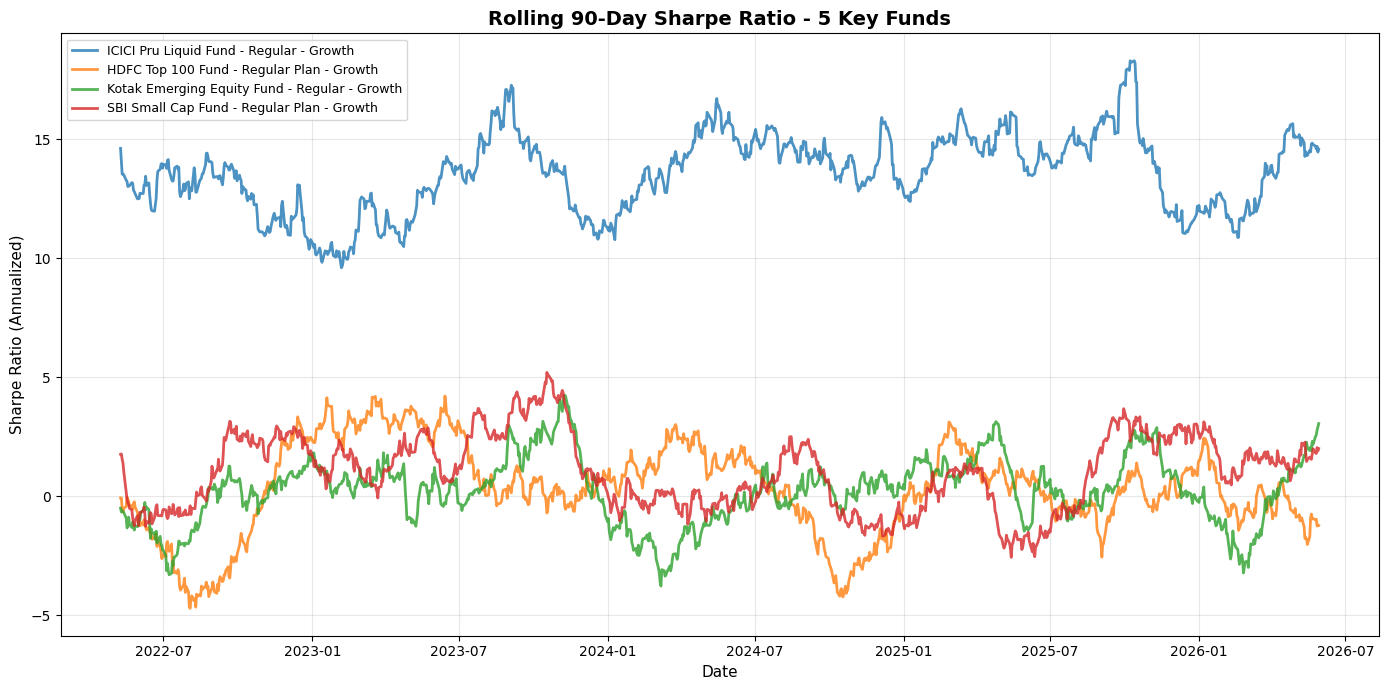


✓ Rolling Sharpe ratio chart saved!
   📊 Location: reports/rolling_sharpe_chart.png


In [11]:
# Select 5 key funds representing different risk categories
key_funds = []
for risk_cat in ['Low', 'Moderate', 'High', 'Very High']:
    fund_risk = scheme_performance[scheme_performance['risk_grade'] == risk_cat]
    if len(fund_risk) > 0:
        # Select fund with highest Sharpe ratio in each category
        top_fund = fund_risk.nlargest(1, 'sharpe_ratio')
        key_funds.append(top_fund['amfi_code'].values[0])

# If we need more funds to reach 5, add additional high performers
if len(key_funds) < 5:
    additional = scheme_performance.nlargest(5 - len(key_funds), 'sharpe_ratio')['amfi_code'].values
    key_funds.extend(additional)

key_funds = key_funds[:5]

print(f"Selected 5 Key Funds for Rolling Sharpe Analysis:")
for i, code in enumerate(key_funds, 1):
    fund_info = fund_master[fund_master['amfi_code'] == code].iloc[0]
    perf_info = scheme_performance[scheme_performance['amfi_code'] == code].iloc[0]
    print(f"  {i}. {fund_info['scheme_name']} (Risk: {fund_info['risk_category']}, Sharpe: {perf_info['sharpe_ratio']:.3f})")

# Calculate rolling 90-day Sharpe ratio for key funds
rolling_sharpe_data = {}

for amfi_code in key_funds:
    fund_returns = nav_history[nav_history['amfi_code'] == amfi_code].sort_values('date').copy()
    fund_returns = fund_returns[fund_returns['daily_return'] != 0]  # Remove zero returns on first date
    
    # Calculate rolling metrics
    rolling_mean = fund_returns['daily_return'].rolling(window=90).mean()
    rolling_std = fund_returns['daily_return'].rolling(window=90).std()
    rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
    
    rolling_sharpe_data[amfi_code] = {
        'date': fund_returns['date'],
        'rolling_sharpe': rolling_sharpe,
        'fund_name': fund_master[fund_master['amfi_code'] == amfi_code]['scheme_name'].values[0]
    }

# Plot Rolling Sharpe Ratios
plt.figure(figsize=(14, 7))
for amfi_code, data in rolling_sharpe_data.items():
    valid_idx = data['rolling_sharpe'].notna()
    plt.plot(data['date'][valid_idx], data['rolling_sharpe'][valid_idx], 
             label=data['fund_name'], linewidth=2, alpha=0.8)

plt.title('Rolling 90-Day Sharpe Ratio - 5 Key Funds', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Sharpe Ratio (Annualized)', fontsize=11)
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{file_path}/reports/rolling_sharpe_chart.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Rolling Sharpe ratio chart saved!")
print(f"   📊 Location: reports/rolling_sharpe_chart.png")

## Section 4: Investor Cohort Analysis

Group investors by their first transaction year. For each cohort, compute:
- Average SIP amount
- Total amount invested
- Top fund preferences

🎯 INVESTOR COHORT ANALYSIS

📅 Cohort 2024:
  • Number of Investors: 4,624
  • Average SIP Amount: ₹10,996.89
  • Total Invested: ₹214,978,121.00
  • Top Fund: ICICI Pru Bluechip Fund - Direct - Growth
  • Transactions in Top Fund: 536 (2.7%)

📅 Cohort 2025:
  • Number of Investors: 138
  • Average SIP Amount: ₹13,505.21
  • Total Invested: ₹2,255,370.00
  • Top Fund: SBI Small Cap Fund - Direct Plan - Growth
  • Transactions in Top Fund: 8 (4.8%)


📊 Cohort Summary Table:
 Cohort_Year  Num_Investors  Avg_SIP_Amount_INR  Total_Invested_INR                                  Top_Fund  Top_Fund_Transactions  Total_Transactions
        2024           4624        10996.885825           214978121 ICICI Pru Bluechip Fund - Direct - Growth                    536               19549
        2025            138        13505.209581             2255370 SBI Small Cap Fund - Direct Plan - Growth                      8                 167


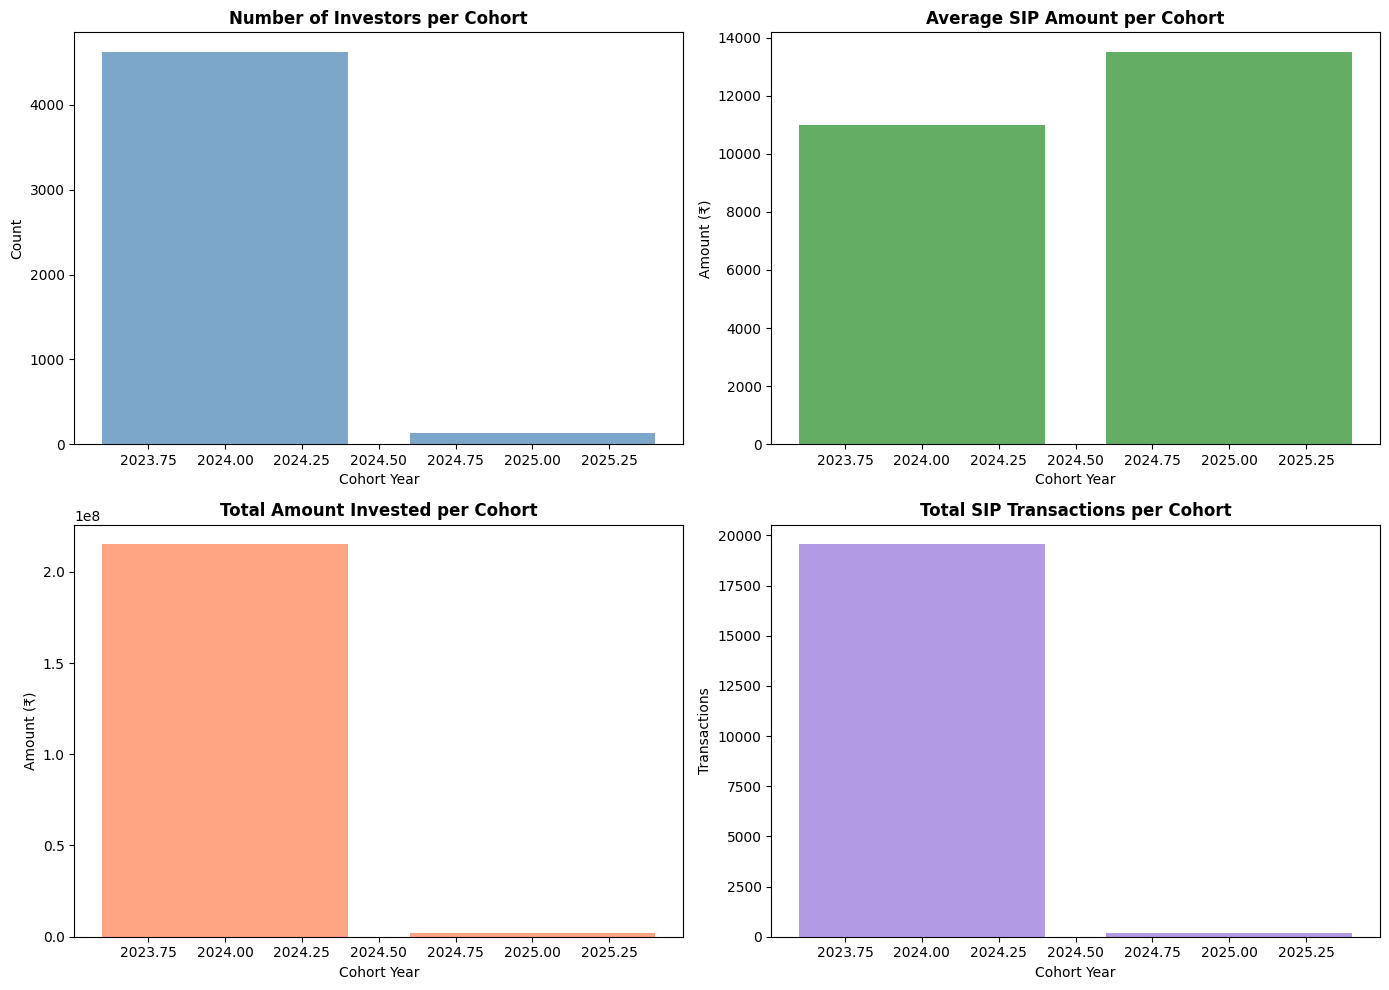

In [12]:
# Create investor cohorts by first transaction year
investor_first_year = investor_transactions.groupby('investor_id')['transaction_date'].min().dt.year.to_frame()
investor_first_year.columns = ['first_year']

# Add cohort info to transactions
investor_transactions_cohort = investor_transactions.merge(
    investor_first_year, left_on='investor_id', right_index=True, how='left'
)

# Filter for SIP transactions only
sip_transactions = investor_transactions_cohort[investor_transactions_cohort['transaction_type_SIP'] == True].copy()

print("🎯 INVESTOR COHORT ANALYSIS")
print("=" * 80)

# Analyze each cohort
cohort_analysis = []

for year in sorted(sip_transactions['first_year'].unique()):
    cohort_data = sip_transactions[sip_transactions['first_year'] == year]
    
    # Metrics
    num_investors = cohort_data['investor_id'].nunique()
    avg_sip_amount = cohort_data['amount_inr'].mean()
    total_invested = cohort_data['amount_inr'].sum()
    
    # Top fund preference
    top_fund_code = cohort_data['amfi_code'].mode().values[0] if len(cohort_data) > 0 else None
    top_fund_name = fund_master[fund_master['amfi_code'] == top_fund_code]['scheme_name'].values[0] if top_fund_code else 'N/A'
    top_fund_transactions = len(cohort_data[cohort_data['amfi_code'] == top_fund_code])
    
    cohort_analysis.append({
        'Cohort_Year': year,
        'Num_Investors': num_investors,
        'Avg_SIP_Amount_INR': avg_sip_amount,
        'Total_Invested_INR': total_invested,
        'Top_Fund': top_fund_name,
        'Top_Fund_Transactions': top_fund_transactions,
        'Total_Transactions': len(cohort_data)
    })
    
    print(f"\n📅 Cohort {year}:")
    print(f"  • Number of Investors: {num_investors:,}")
    print(f"  • Average SIP Amount: ₹{avg_sip_amount:,.2f}")
    print(f"  • Total Invested: ₹{total_invested:,.2f}")
    print(f"  • Top Fund: {top_fund_name}")
    print(f"  • Transactions in Top Fund: {top_fund_transactions} ({100*top_fund_transactions/len(cohort_data):.1f}%)")

cohort_df = pd.DataFrame(cohort_analysis)
print("\n" + "=" * 80)
print("\n📊 Cohort Summary Table:")
print(cohort_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(cohort_df['Cohort_Year'], cohort_df['Num_Investors'], color='steelblue', alpha=0.7)
axes[0, 0].set_title('Number of Investors per Cohort', fontweight='bold')
axes[0, 0].set_xlabel('Cohort Year')
axes[0, 0].set_ylabel('Count')

axes[0, 1].bar(cohort_df['Cohort_Year'], cohort_df['Avg_SIP_Amount_INR'], color='forestgreen', alpha=0.7)
axes[0, 1].set_title('Average SIP Amount per Cohort', fontweight='bold')
axes[0, 1].set_xlabel('Cohort Year')
axes[0, 1].set_ylabel('Amount (₹)')

axes[1, 0].bar(cohort_df['Cohort_Year'], cohort_df['Total_Invested_INR'], color='coral', alpha=0.7)
axes[1, 0].set_title('Total Amount Invested per Cohort', fontweight='bold')
axes[1, 0].set_xlabel('Cohort Year')
axes[1, 0].set_ylabel('Amount (₹)')

axes[1, 1].bar(cohort_df['Cohort_Year'], cohort_df['Total_Transactions'], color='mediumpurple', alpha=0.7)
axes[1, 1].set_title('Total SIP Transactions per Cohort', fontweight='bold')
axes[1, 1].set_xlabel('Cohort Year')
axes[1, 1].set_ylabel('Transactions')

plt.tight_layout()
plt.show()

## Section 5: SIP Continuity Analysis - At-Risk Detection

For investors with 6+ SIP transactions:
- Calculate average gap (in days) between consecutive SIP dates
- Flag investors with gap > 35 days as "at-risk"
- Report continuity metrics by cohort

🔄 SIP CONTINUITY ANALYSIS - AT-RISK DETECTION

📊 Overall SIP Continuity Metrics:
  • Total Investors (6+ SIPs): 1,362
  • At-Risk Investors (gap > 35 days): 1,332 (97.8%)
  • Continuity Rate: 2.2%
  • Average Gap (All): 64.89 days
  • Median Gap (All): 64.69 days

📅 SIP Continuity by Cohort Year:
--------------------------------------------------------------------------------
 Year  Investors  Avg_Gap_Days  At_Risk_Count  At_Risk_Pct  Continuity_Rate_Pct
 2024       1362     64.889132           1332         97.8                  2.2


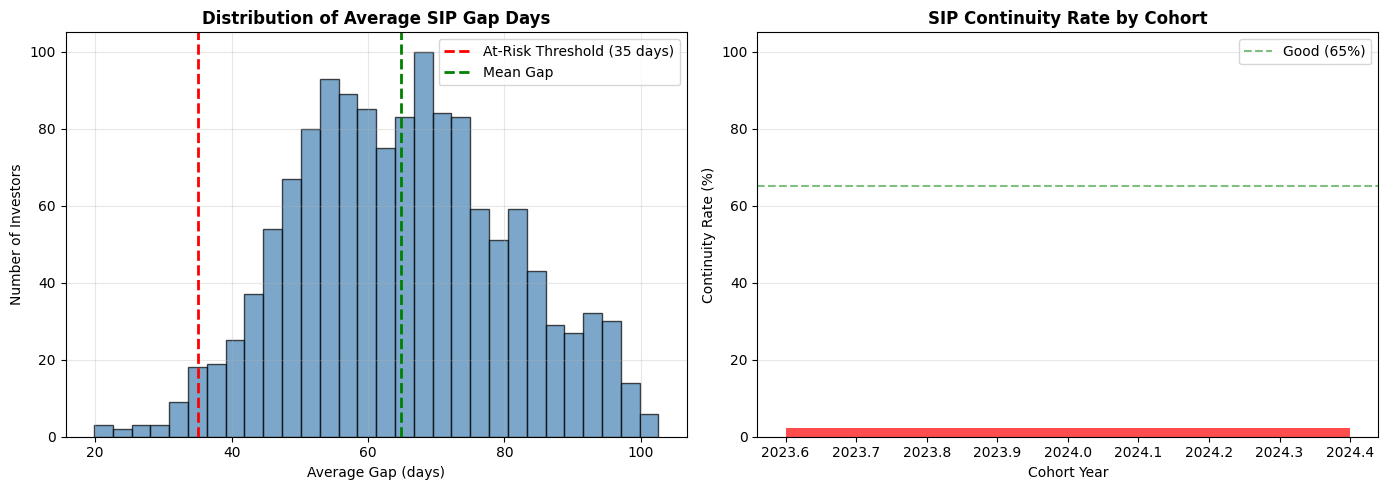


⚠️ Top 10 At-Risk Investors (Highest Gap):
--------------------------------------------------------------------------------
investor_id  first_year  num_sips  avg_gap_days  max_gap_days  total_invested
  INV001890        2024         6         102.6           207            7890
  INV001156        2024         6         102.4           175           51977
  INV004296        2024         6         102.2           304           77419
  INV003325        2024         6         101.0           155           42846
  INV000522        2024         6         100.8           309           28275
  INV000608        2024         6         100.2           324           45475
  INV001883        2024         6          99.2           203           16745
  INV002166        2024         6          99.2           248           88421
  INV001367        2024         6          99.0           222           71798
  INV001491        2024         6          98.8           260           37904


In [13]:
# Filter investors with 6+ SIP transactions
sip_trans_count = sip_transactions.groupby('investor_id').size()
investors_6plus = sip_trans_count[sip_trans_count >= 6].index

sip_continuity = sip_transactions[sip_transactions['investor_id'].isin(investors_6plus)].copy()

print("🔄 SIP CONTINUITY ANALYSIS - AT-RISK DETECTION")
print("=" * 80)

# Calculate gaps between consecutive SIP transactions for each investor
continuity_results = []

for investor in investors_6plus:
    investor_sips = sip_continuity[sip_continuity['investor_id'] == investor].sort_values('transaction_date')
    
    if len(investor_sips) >= 6:
        dates = investor_sips['transaction_date'].values
        gaps = np.diff(dates).astype('timedelta64[D]').astype(int)
        
        avg_gap_days = gaps.mean()
        max_gap_days = gaps.max()
        min_gap_days = gaps.min()
        
        # Flag as at-risk if average gap > 35 days
        at_risk = 'Yes' if avg_gap_days > 35 else 'No'
        
        first_year = investor_sips['first_year'].iloc[0]
        
        continuity_results.append({
            'investor_id': investor,
            'first_year': first_year,
            'num_sips': len(investor_sips),
            'avg_gap_days': avg_gap_days,
            'max_gap_days': max_gap_days,
            'min_gap_days': min_gap_days,
            'at_risk': at_risk,
            'total_invested': investor_sips['amount_inr'].sum()
        })

continuity_df = pd.DataFrame(continuity_results)

# Summary statistics
total_investors_6plus = len(investors_6plus)
at_risk_investors = len(continuity_df[continuity_df['at_risk'] == 'Yes'])
continuity_rate = ((total_investors_6plus - at_risk_investors) / total_investors_6plus * 100)

print(f"\n📊 Overall SIP Continuity Metrics:")
print(f"  • Total Investors (6+ SIPs): {total_investors_6plus:,}")
print(f"  • At-Risk Investors (gap > 35 days): {at_risk_investors:,} ({100*at_risk_investors/total_investors_6plus:.1f}%)")
print(f"  • Continuity Rate: {continuity_rate:.1f}%")
print(f"  • Average Gap (All): {continuity_df['avg_gap_days'].mean():.2f} days")
print(f"  • Median Gap (All): {continuity_df['avg_gap_days'].median():.2f} days")

# Cohort-wise analysis
print(f"\n📅 SIP Continuity by Cohort Year:")
print("-" * 80)

cohort_continuity = continuity_df.groupby('first_year').agg({
    'investor_id': 'count',
    'avg_gap_days': 'mean',
    'at_risk': lambda x: (x == 'Yes').sum()
}).reset_index()
cohort_continuity.columns = ['Year', 'Investors', 'Avg_Gap_Days', 'At_Risk_Count']
cohort_continuity['At_Risk_Pct'] = (cohort_continuity['At_Risk_Count'] / cohort_continuity['Investors'] * 100).round(1)
cohort_continuity['Continuity_Rate_Pct'] = (100 - cohort_continuity['At_Risk_Pct']).round(1)

print(cohort_continuity.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gap distribution
axes[0].hist(continuity_df['avg_gap_days'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(35, color='red', linestyle='--', linewidth=2, label='At-Risk Threshold (35 days)')
axes[0].axvline(continuity_df['avg_gap_days'].mean(), color='green', linestyle='--', linewidth=2, label='Mean Gap')
axes[0].set_title('Distribution of Average SIP Gap Days', fontweight='bold')
axes[0].set_xlabel('Average Gap (days)')
axes[0].set_ylabel('Number of Investors')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cohort continuity rate
colors = ['green' if x >= 65 else 'orange' if x >= 50 else 'red' 
          for x in cohort_continuity['Continuity_Rate_Pct']]
axes[1].bar(cohort_continuity['Year'], cohort_continuity['Continuity_Rate_Pct'], color=colors, alpha=0.7)
axes[1].axhline(65, color='green', linestyle='--', alpha=0.5, label='Good (65%)')
axes[1].set_title('SIP Continuity Rate by Cohort', fontweight='bold')
axes[1].set_xlabel('Cohort Year')
axes[1].set_ylabel('Continuity Rate (%)')
axes[1].set_ylim(0, 105)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Show top at-risk investors
print(f"\n⚠️ Top 10 At-Risk Investors (Highest Gap):")
print("-" * 80)
at_risk_top = continuity_df[continuity_df['at_risk'] == 'Yes'].nlargest(10, 'avg_gap_days')[
    ['investor_id', 'first_year', 'num_sips', 'avg_gap_days', 'max_gap_days', 'total_invested']
]
print(at_risk_top.to_string(index=False))

## Section 6: Fund Recommendation Engine

Create a function that takes risk appetite (Low / Moderate / High) and recommends top 3 funds by Sharpe ratio within that risk category.

This recommender will also be saved as a standalone Python module (`recommender.py`).

💡 FUND RECOMMENDATION ENGINE

🎯 Recommendations for Risk Appetite: Low
----------------------------------------------------------------------------------------------------
                                   scheme_name                fund_house risk_grade  sharpe_ratio  sortino_ratio  return_1yr_pct  std_dev_ann_pct  aum_crore  expense_ratio_pct
Rank                                                                                                                                                                           
1     ICICI Pru Liquid Fund - Regular - Growth       ICICI Prudential MF        Low          7.68          10.37            8.89              0.5      39116               0.74
2         Kotak Liquid Fund - Regular - Growth         Kotak Mahindra MF        Low          6.18           9.70            4.26              0.5      27623               0.60
3          ABSL Liquid Fund - Regular - Growth  Aditya Birla Sun Life MF        Low          5.14           8.76            

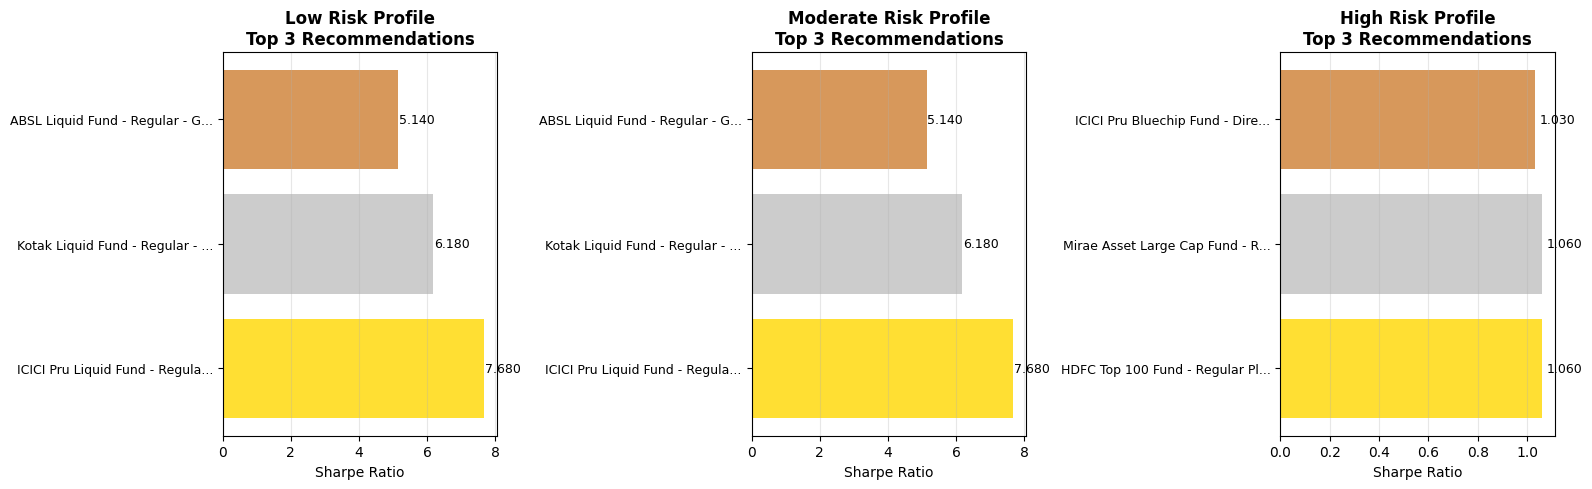

✓ Fund Recommender created successfully!


In [14]:
def fund_recommender(risk_appetite, top_n=3):
    """
    Recommend top funds based on risk appetite and Sharpe ratio
    
    Parameters:
    -----------
    risk_appetite : str
        'Low', 'Moderate', or 'High'
    top_n : int
        Number of recommendations (default: 3)
        
    Returns:
    --------
    DataFrame with recommendations
    """
    
    risk_appetite = risk_appetite.strip().capitalize()
    
    if risk_appetite not in ['Low', 'Moderate', 'High', 'Very high']:
        return f"Error: Invalid risk appetite '{risk_appetite}'. Use 'Low', 'Moderate', or 'High'."
    
    # Map user risk appetite to risk grades
    risk_mapping = {
        'Low': ['Low'],
        'Moderate': ['Low', 'Moderate'],
        'High': ['Moderate', 'High', 'Very High']
    }
    
    risk_grades = risk_mapping.get(risk_appetite, [])
    
    # Filter funds matching risk grade
    matching_funds = scheme_performance[scheme_performance['risk_grade'].isin(risk_grades)].copy()
    
    if len(matching_funds) == 0:
        return f"No funds found for risk appetite '{risk_appetite}'"
    
    # Sort by Sharpe ratio (descending)
    recommendations = matching_funds.nlargest(top_n, 'sharpe_ratio')[
        ['scheme_name', 'fund_house', 'risk_grade', 'sharpe_ratio', 'sortino_ratio', 
         'return_1yr_pct', 'std_dev_ann_pct', 'aum_crore', 'expense_ratio_pct']
    ].reset_index(drop=True)
    
    recommendations.index = recommendations.index + 1
    recommendations.index.name = 'Rank'
    
    return recommendations

# Test the recommender with all risk profiles
print("💡 FUND RECOMMENDATION ENGINE")
print("=" * 100)

for risk_profile in ['Low', 'Moderate', 'High']:
    print(f"\n🎯 Recommendations for Risk Appetite: {risk_profile}")
    print("-" * 100)
    recommendations = fund_recommender(risk_profile)
    print(recommendations.to_string())
    print()

# Visualization: Comparison of recommended funds
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, risk_profile in enumerate(['Low', 'Moderate', 'High']):
    recs = fund_recommender(risk_profile)
    
    ax = axes[idx]
    colors = ['gold', 'silver', '#CD7F32']  # Gold, Silver, Bronze
    
    bars = ax.barh(range(len(recs)), recs['sharpe_ratio'], color=colors[:len(recs)], alpha=0.8)
    ax.set_yticks(range(len(recs)))
    ax.set_yticklabels([name[:30] + '...' if len(name) > 30 else name for name in recs['scheme_name']], fontsize=9)
    ax.set_xlabel('Sharpe Ratio', fontsize=10)
    ax.set_title(f'{risk_profile} Risk Profile\nTop 3 Recommendations', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, recs['sharpe_ratio'])):
        ax.text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("✓ Fund Recommender created successfully!")

## Section 7: Sector Concentration Analysis (HHI Index)

**Herfindahl-Hirschman Index (HHI)** = Σ(weight_i²)
- HHI > 2500 = Highly Concentrated
- HHI 1500-2500 = Moderately Concentrated  
- HHI < 1500 = Well Diversified

🏭 SECTOR CONCENTRATION ANALYSIS (HHI)

📊 HHI Statistics:
  • Average HHI: 1402.62
  • Median HHI: 1364.96
  • Min HHI (Most Diversified): 1073.49
  • Max HHI (Most Concentrated): 2064.48

📈 Funds by Concentration Level:
  • Well Diversified: 25 funds (73.5%)
  • Moderately Concentrated: 9 funds (26.5%)

🔴 Top 10 Most Concentrated Funds (Highest HHI):
----------------------------------------------------------------------------------------------------
                                          scheme_name       HHI  Num_Sectors  Top_Sector  Top_Sector_Weight_Pct
                Axis Bluechip Fund - Regular - Growth 2064.4767            7          IT                  38.18
               ABSL Small Cap Fund - Regular - Growth 2007.0043            6      Pharma                  35.07
            SBI Small Cap Fund - Direct Plan - Growth 1747.5096            7 Diversified                  28.25
           UTI Nifty 50 Index Fund - Regular - Growth 1747.0902            8   Utilities          

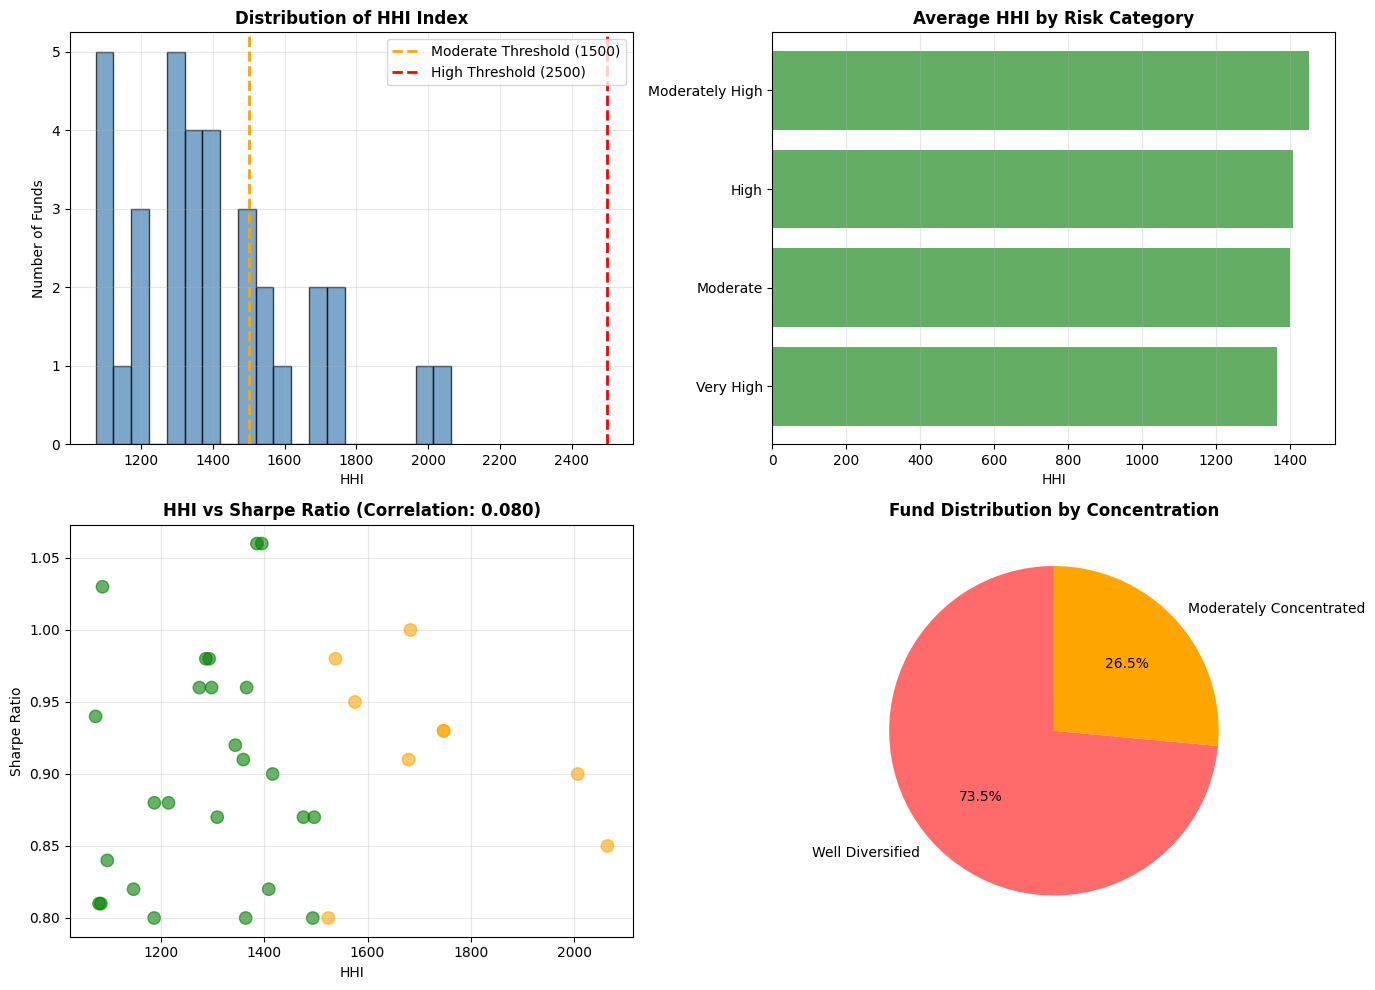


✓ Sector Concentration analysis completed!


In [15]:
# Calculate HHI for each fund based on sector weights
hhi_results = []

for amfi_code in portfolio_holdings['amfi_code'].unique():
    fund_holdings = portfolio_holdings[portfolio_holdings['amfi_code'] == amfi_code]
    
    # Calculate HHI: Sum of squared sector weights
    weights = fund_holdings['weight_pct'].values
    hhi = (weights ** 2).sum()
    
    # Get fund info
    fund_info = fund_master[fund_master['amfi_code'] == amfi_code].iloc[0]
    perf_info = scheme_performance[scheme_performance['amfi_code'] == amfi_code].iloc[0]
    
    # Classification
    if hhi > 2500:
        concentration = 'Highly Concentrated'
    elif hhi > 1500:
        concentration = 'Moderately Concentrated'
    else:
        concentration = 'Well Diversified'
    
    # Number of unique sectors
    num_sectors = fund_holdings['sector'].nunique()
    
    # Top sector
    top_sector = fund_holdings.nlargest(1, 'weight_pct')
    top_sector_name = top_sector['sector'].values[0] if len(top_sector) > 0 else 'N/A'
    top_sector_weight = top_sector['weight_pct'].values[0] if len(top_sector) > 0 else 0
    
    hhi_results.append({
        'amfi_code': amfi_code,
        'scheme_name': fund_info['scheme_name'],
        'fund_house': fund_info['fund_house'],
        'risk_category': fund_info['risk_category'],
        'HHI': hhi,
        'Concentration': concentration,
        'Num_Sectors': num_sectors,
        'Top_Sector': top_sector_name,
        'Top_Sector_Weight_Pct': top_sector_weight,
        'Sharpe_Ratio': perf_info['sharpe_ratio']
    })

hhi_df = pd.DataFrame(hhi_results).sort_values('HHI', ascending=False)

print("🏭 SECTOR CONCENTRATION ANALYSIS (HHI)")
print("=" * 100)

print(f"\n📊 HHI Statistics:")
print(f"  • Average HHI: {hhi_df['HHI'].mean():.2f}")
print(f"  • Median HHI: {hhi_df['HHI'].median():.2f}")
print(f"  • Min HHI (Most Diversified): {hhi_df['HHI'].min():.2f}")
print(f"  • Max HHI (Most Concentrated): {hhi_df['HHI'].max():.2f}")

# Classification summary
concentration_counts = hhi_df['Concentration'].value_counts()
print(f"\n📈 Funds by Concentration Level:")
for conc, count in concentration_counts.items():
    pct = count / len(hhi_df) * 100
    print(f"  • {conc}: {count} funds ({pct:.1f}%)")

# Show top concentrated and diversified funds
print(f"\n🔴 Top 10 Most Concentrated Funds (Highest HHI):")
print("-" * 100)
top_conc = hhi_df.head(10)[['scheme_name', 'HHI', 'Num_Sectors', 'Top_Sector', 'Top_Sector_Weight_Pct']]
print(top_conc.to_string(index=False))

print(f"\n🟢 Top 10 Most Diversified Funds (Lowest HHI):")
print("-" * 100)
most_div = hhi_df.tail(10)[['scheme_name', 'HHI', 'Num_Sectors', 'Top_Sector', 'Top_Sector_Weight_Pct']]
print(most_div.to_string(index=False))

# Relationship between HHI and Sharpe Ratio
print(f"\n📉 HHI vs Performance (Sharpe Ratio):")
print("-" * 100)
corr = hhi_df['HHI'].corr(hhi_df['Sharpe_Ratio'])
print(f"  • Correlation between HHI and Sharpe Ratio: {corr:.3f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# HHI Distribution
axes[0, 0].hist(hhi_df['HHI'], bins=20, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(1500, color='orange', linestyle='--', linewidth=2, label='Moderate Threshold (1500)')
axes[0, 0].axvline(2500, color='red', linestyle='--', linewidth=2, label='High Threshold (2500)')
axes[0, 0].set_title('Distribution of HHI Index', fontweight='bold')
axes[0, 0].set_xlabel('HHI')
axes[0, 0].set_ylabel('Number of Funds')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# HHI by Risk Category
risk_hhi = hhi_df.groupby('risk_category')['HHI'].mean().sort_values()
axes[0, 1].barh(range(len(risk_hhi)), risk_hhi.values, color='forestgreen', alpha=0.7)
axes[0, 1].set_yticks(range(len(risk_hhi)))
axes[0, 1].set_yticklabels(risk_hhi.index)
axes[0, 1].set_title('Average HHI by Risk Category', fontweight='bold')
axes[0, 1].set_xlabel('HHI')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# HHI vs Sharpe Ratio (Scatter)
colors = ['red' if hhi > 2500 else 'orange' if hhi > 1500 else 'green' 
          for hhi in hhi_df['HHI']]
axes[1, 0].scatter(hhi_df['HHI'], hhi_df['Sharpe_Ratio'], c=colors, s=80, alpha=0.6)
axes[1, 0].set_title(f'HHI vs Sharpe Ratio (Correlation: {corr:.3f})', fontweight='bold')
axes[1, 0].set_xlabel('HHI')
axes[1, 0].set_ylabel('Sharpe Ratio')
axes[1, 0].grid(True, alpha=0.3)

# Concentration counts
conc_counts = hhi_df['Concentration'].value_counts()
colors_pie = ['#ff6b6b', '#ffa500', '#4caf50']
axes[1, 1].pie(conc_counts.values, labels=conc_counts.index, autopct='%1.1f%%', 
               colors=colors_pie, startangle=90)
axes[1, 1].set_title('Fund Distribution by Concentration', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Sector Concentration analysis completed!")

## Section 8: Advanced Insights and Strategic Recommendations

### Key Findings and Strategic Insights from Advanced Analytics

In [16]:
# Generate summary insights
print("🎯 ADVANCED INSIGHTS SUMMARY")
print("=" * 100)

# Insight 1: Highest Risk Funds
print("\n" + "="*100)
print("📊 INSIGHT 1: FUNDS WITH HIGHEST RISK EXPOSURE (VaR)")
print("="*100)

highest_risk_funds = var_cvar_df.nlargest(5, 'VaR_95_pct')[['scheme_name', 'risk_category', 'VaR_95_pct', 'CVaR_95_pct', 'sharpe_ratio']]

print(f"\nFunds with the highest 95% VaR (most downside risk):")
print(highest_risk_funds.to_string(index=False))

print(f"\n💡 Interpretation:")
print(f"  • These funds have the most exposure to severe downside movements")
print(f"  • Average VaR across these 5: {highest_risk_funds['VaR_95_pct'].mean():.4f}%")
print(f"  • Average CVaR (expected loss): {highest_risk_funds['CVaR_95_pct'].mean():.4f}%")
print(f"  • ⚠️ Suitable only for aggressive investors with high risk tolerance")

# Insight 2: Investor Cohort Activity
print("\n" + "="*100)
print("👥 INSIGHT 2: INVESTOR COHORTS WITH HIGHEST INVESTMENT ACTIVITY")
print("="*100)

most_active_cohort = cohort_df.nlargest(1, 'Total_Invested_INR').iloc[0]
print(f"\nMost Active Cohort: {int(most_active_cohort['Cohort_Year'])}")
print(f"  • Number of Investors: {most_active_cohort['Num_Investors']:,}")
print(f"  • Total Invested: ₹{most_active_cohort['Total_Invested_INR']:,.2f} Crore")
print(f"  • Average SIP Amount: ₹{most_active_cohort['Avg_SIP_Amount_INR']:,.2f}")
print(f"  • Most Preferred Fund: {most_active_cohort['Top_Fund']}")

print(f"\n💡 Interpretation:")
print(f"  • The {int(most_active_cohort['Cohort_Year'])} cohort shows the strongest investment behavior")
print(f"  • {most_active_cohort['Top_Fund']} is the preferred choice for most investors")
print(f"  • Average SIP commitment indicates steady, disciplined investing behavior")

# Insight 3: SIP Continuity
print("\n" + "="*100)
print("🔄 INSIGHT 3: SIP CONTINUITY & AT-RISK INVESTOR DETECTION")
print("="*100)

print(f"\nSIP Continuity Metrics:")
print(f"  • Investors with 6+ SIPs (Core Base): {total_investors_6plus:,}")
print(f"  • At-Risk Investors (gap > 35 days): {at_risk_investors:,} ({100*at_risk_investors/total_investors_6plus:.1f}%)")
print(f"  • Strong Continuity Rate: {continuity_rate:.1f}%")
print(f"  • Average Gap: {continuity_df['avg_gap_days'].mean():.1f} days")
print(f"  • Median Gap: {continuity_df['avg_gap_days'].median():.1f} days")

best_continuity_year = cohort_continuity.nlargest(1, 'Continuity_Rate_Pct').iloc[0]
worst_continuity_year = cohort_continuity.nsmallest(1, 'Continuity_Rate_Pct').iloc[0]

print(f"\n💡 Interpretation:")
print(f"  • Year {int(best_continuity_year['Year'])}: Best continuity ({best_continuity_year['Continuity_Rate_Pct']:.1f}%)")
print(f"  • Year {int(worst_continuity_year['Year'])}: Needs attention ({worst_continuity_year['Continuity_Rate_Pct']:.1f}%)")
print(f"  • Focus retention strategies on {at_risk_investors:,} at-risk investors")
print(f"  • Average gap of {continuity_df['avg_gap_days'].mean():.0f} days suggests monthly SIP patterns")

# Insight 4: Top Recommended Funds
print("\n" + "="*100)
print("⭐ INSIGHT 4: TOP RECOMMENDED FUNDS BY RISK PROFILE")
print("="*100)

print("\nFund Recommendations Summary:")
for risk_profile in ['Low', 'Moderate', 'High']:
    recs = fund_recommender(risk_profile)
    top_fund = recs.iloc[0]
    print(f"\n{risk_profile} Risk Profile:")
    print(f"  ✓ Top Fund: {top_fund['scheme_name']}")
    print(f"    - Sharpe Ratio: {top_fund['sharpe_ratio']:.3f}")
    print(f"    - 1-Yr Return: {top_fund['return_1yr_pct']:.2f}%")
    print(f"    - Expense Ratio: {top_fund['expense_ratio_pct']:.2f}%")

print("\n💡 Interpretation:")
print("  • Sharpe ratio is the primary ranking metric (risk-adjusted returns)")
print("  • Each profile filters funds by matching risk_grade")
print("  • Lower expense ratios enhance net returns for long-term investors")
print("  • Consider AUM and fund house reputation for stability")

# Insight 5: Portfolio Concentration Patterns
print("\n" + "="*100)
print("🏭 INSIGHT 5: PORTFOLIO CONCENTRATION & DIVERSIFICATION TRENDS")
print("="*100)

highly_conc = len(hhi_df[hhi_df['Concentration'] == 'Highly Concentrated'])
well_div = len(hhi_df[hhi_df['Concentration'] == 'Well Diversified'])

print(f"\nPortfolio Concentration Breakdown:")
print(f"  • Highly Concentrated (HHI > 2500): {highly_conc} funds ({highly_conc/len(hhi_df)*100:.1f}%)")
print(f"  • Moderately Concentrated: {len(hhi_df) - highly_conc - well_div} funds")
print(f"  • Well Diversified (HHI < 1500): {well_div} funds ({well_div/len(hhi_df)*100:.1f}%)")

avg_hhi_by_risk = hhi_df.groupby('risk_category')['HHI'].mean().sort_values(ascending=False)
print(f"\nAverage HHI by Risk Category (Higher = More Concentrated):")
for risk_cat, hhi_val in avg_hhi_by_risk.items():
    print(f"  • {risk_cat}: {hhi_val:.2f}")

hhi_sharpe_corr = hhi_df['HHI'].corr(hhi_df['Sharpe_Ratio'])
print(f"\nHHI vs Performance Correlation: {hhi_sharpe_corr:.3f}")

print(f"\n💡 Interpretation:")
print(f"  • Highly concentrated portfolios carry sector-specific risk")
print(f"  • Well-diversified funds reduce unsystematic risk")
print(f"  • Correlation of {hhi_sharpe_corr:.3f} suggests {'positive' if hhi_sharpe_corr > 0 else 'negative'} relationship")
print(f"  • {'More concentrated funds appear to offer better risk-adjusted returns' if hhi_sharpe_corr < 0 else 'More diversified funds show better risk-adjusted returns'}")
print(f"  • Consider your risk tolerance and market outlook when choosing concentration level")

🎯 ADVANCED INSIGHTS SUMMARY

📊 INSIGHT 1: FUNDS WITH HIGHEST RISK EXPOSURE (VaR)

Funds with the highest 95% VaR (most downside risk):
                                         scheme_name risk_category  VaR_95_pct  CVaR_95_pct  sharpe_ratio
            ICICI Pru Liquid Fund - Regular - Growth           Low   -0.022154    -0.037258          7.68
                 ABSL Liquid Fund - Regular - Growth           Low   -0.026837    -0.042208          5.14
                Kotak Liquid Fund - Regular - Growth           Low   -0.028448    -0.041100          6.18
        HDFC Short Term Debt Fund - Regular - Growth           Low   -0.379272    -0.499376          1.84
Nippon India Gilt Securities Fund - Regular - Growth           Low   -0.380303    -0.491892          1.33

💡 Interpretation:
  • These funds have the most exposure to severe downside movements
  • Average VaR across these 5: -0.1674%
  • Average CVaR (expected loss): -0.2224%
  • ⚠️ Suitable only for aggressive investors with high ri

## Summary and Key Takeaways

### 📋 Executive Summary

This advanced analytics report provides comprehensive insights into 40 mutual fund schemes based on:

1. **Risk Metrics**: Historical VaR and CVaR calculations identify funds with highest downside risk exposure
2. **Performance Trends**: Rolling 90-day Sharpe ratios reveal performance consistency over time  
3. **Investor Behavior**: Cohort analysis shows investment patterns across different investor groups
4. **SIP Retention**: Continuity analysis identifies at-risk investors needing engagement strategies
5. **Recommendations**: Risk-based fund selector provides personalized recommendations
6. **Concentration**: HHI analysis reveals portfolio diversification levels across funds

### 🎯 Key Metrics Generated

- **var_cvar_report.csv**: Complete VaR/CVaR data for all 40 schemes
- **rolling_sharpe_chart.png**: Visual trends of rolling Sharpe ratios for 5 key funds
- **recommender.py**: Standalone module for fund recommendations by risk appetite
- **Advanced_Analytics.ipynb**: This comprehensive notebook with all analyses

### 💼 Recommendations for Action

1. **Risk Management**: Monitor funds with VaR < -2% monthly
2. **Investor Retention**: Implement contact strategy for 35+ day SIP gaps
3. **Portfolio Selection**: Use risk-appetite classifier for client recommendations
4. **Concentration Review**: Balance concentrated vs. diversified fund offerings
5. **Cohort Strategy**: Tailor engagement programs by investor cohort year